# Beta-VAE Causal CelebA Interpolation

Here, a beta-VAE is trained. This serves as one of our benchmarks because a beta-VAE is a method claiming to produce independent components in the latent space.

Since the causalNF model is trained leveraging information about the interventional targets, we are able to control which part of the latent space corresponds to hair color attribute. Since the beta-VAE does not know that information apriori, we perform a grid search to determine the latent space that is most highly correlated with hair color attribute, and then perform the interpolation on that space. This serves as our benchmark.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from copy import copy
from pathlib import Path
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import lightning as pl
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import transforms
from torchvision.utils import save_image, make_grid

from ciflows.datasets.causalceleba import CausalCelebA
from ciflows.eval import load_model
from ciflows.reduction.resnetvae import DeepResNetVAE
from ciflows.datasets.causalceleba_scm.pretrained import MultiTaskResNet

import copy
from ciflows.diffusion.ddpm.wrapper import DDPMWrapper
from ciflows.diffusion.ddpm.ddpm_form2 import DDPMv2
from ciflows.diffusion.ddpm.ddpm import DDPM
from ciflows.diffusion.ddpm.unet_openai import SuperResModel
from ciflows.diffusion.ddpm.vae import VAE as BACKVAE

TypeError: expected string or bytes-like object

In [3]:

graph_type = "chain"
debug = False
if debug:
    root = Path("/Users/adam2392/pytorch_data/")
else:
    root = Path("/home/adam2392/projects/data/")
    root = Path("/local/eb/adam2392/")

scm_model = "CausalDigitBarMNIST"

data_dir = root / scm_model / graph_type

data_to_encode = data_dir / 'chain-imgs-train.pt'
data_tensor = torch.load(data_to_encode)

print(data_tensor.shape)

/tmp/ipykernel_3190195/4084974555.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_tensor = torch.load(data_to_encode)


AttributeError: 'list' object has no attribute 'shape'

In [ ]:
print(len(data_tensor))

In [3]:
print(torch.__version__)

2.5.1.post207


In [4]:

# Option 2: Display the grid using matplotlib
def tensor_to_numpy(image_tensor):
    # Convert from tensor to NumPy for plotting
    image = image_tensor.cpu().permute(1, 2, 0)  # (C, H, W) -> (H, W, C)
    return image.numpy()

## Setup - directories and GPU selection

In [5]:
root = Path("/Users/adam2392/pytorch_data/")
root = Path('/local/eb/adam2392/')
seed_offset = 1

# set seed
seed = 1234
np.random.seed(seed + seed_offset)
pl.seed_everything(seed + seed_offset, workers=True)

image_size = 128
latent_dim = 48
num_blocks_per_stage = 3
debug = False

if torch.cuda.is_available():
    device = torch.device("cuda")
    accelerator = "cuda"

    # Get the index of the current device
    device_index = 0
    device = torch.device(f"cuda:{device_index}")
    print(f"Current CUDA device index: {device_index}")

    # Get the name of the current device
    device_name = torch.cuda.get_device_name(device_index)
    print(f"Current CUDA device name: {device_name}")

    num_devices = torch.cuda.device_count()
    device_names = [torch.cuda.get_device_name(i) for i in range(num_devices)]
    print('NUm devices: ', num_devices)
    print(device_names)
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    accelerator = "mps"
else:
    device = torch.device("cpu")
    accelerator = "cpu"

print(f"Using device: {device}")
print(f"Using accelerator: {accelerator}")

Seed set to 1235


Current CUDA device index: 0
Current CUDA device name: NVIDIA H100 80GB HBM3
NUm devices:  8
['NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3', 'NVIDIA H100 80GB HBM3']
Using device: cuda:0
Using accelerator: cuda


## Load relevant model

Here, we load the already trained models: ResNet-VAE, causal NF and the diffusion deblurring model

In [6]:
# Haircolor SCM with VAE and 128-flow NF model l1 loss
vae_model_dir = 'celeba_cyclicbetal1loss_haircolorscm_vaeresnetreduction_batch128_gradaccum_latentdim48_img128_v1'
vae_model_fname = "model_epoch_15670.pt"

vae_dir = root / "CausalCelebA" / "vae_reduction" / 'haircolor' / vae_model_dir.split(".")[0]
model_path = vae_dir / vae_model_fname

vae_model = DeepResNetVAE(latent_dim, num_blocks_per_stage=num_blocks_per_stage)
print("Loading VAE model from: ", model_path)
vae_model, _ = load_model(vae_model, model_path, device)
vae_model = vae_model.to(device)

image_dim = 3 * image_size * image_size


Loading VAE model from:  /local/eb/adam2392/CausalCelebA/vae_reduction/haircolor/celeba_cyclicbetal1loss_haircolorscm_vaeresnetreduction_batch128_gradaccum_latentdim48_img128_v1/model_epoch_15670.pt


/home/adam2392/projects/ciflows/ciflows/eval.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


Model loaded from /local/eb/adam2392/CausalCelebA/vae_reduction/haircolor/celeba_cyclicbetal1loss_haircolorscm_vaeresnetreduction_batch128_gradaccum_latentdim48_img128_v1/model_epoch_15670.pt


## Setup Dataset and DataLoader

Here, we'll load in the CelebA dataset and specifically a batch of blond hair images
and a batch of black hair images.

In [7]:
img_size = 128
graph_type = 'chain'

# Define the image transformations
image_transform = transforms.Compose(
    [
        transforms.Resize((img_size, img_size)),  # Resize images to 128x128
        transforms.CenterCrop(img_size),  # Ensure square crop
        transforms.ToTensor(),  # Convert images to PyTorch tensors
        # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)
causal_celeba_dataset = CausalCelebA(
    root=root,
    graph_type=graph_type,
    transform=image_transform,
    img_size=img_size,
    fast_dev_run=False,  # Set to True for debugging
)

Processing intervention type: Haircolor


In [8]:
causal_celeba_dataset.causal_main_df.columns
print(causal_celeba_dataset.causal_main_df['Hair Color'])
print(len(causal_celeba_dataset.file_list))

0        Black
1         Gray
2         Gray
3        Black
4         Gray
         ...  
79995     Gray
79996     Gray
79997     Gray
79998     Gray
79999     Gray
Name: Hair Color, Length: 80000, dtype: object
80000


In [9]:
display(causal_celeba_dataset.causal_main_df.head())

,Gender,Age,Hair Color,Sample Index,distr_type,distr_idx
0,Male,Old,Black,22439,obs,0
1,Female,Young,Gray,59611,obs,0
2,Female,Young,Gray,102554,obs,0
3,Male,Young,Black,140485,obs,0
4,Female,Old,Gray,4861,obs,0


In [10]:
print(len(causal_celeba_dataset))
batch_size = 16
blond_hair_batch, blond_idx = causal_celeba_dataset.sample(
    n_samples=batch_size, attr_name="Hair Color", attr_val='Gray', seed=12
)

black_hair_batch, black_idx = causal_celeba_dataset.sample(
    n_samples=batch_size, attr_name="Hair Color", attr_val='Black', seed=12
)

print('Blondidx: ',blond_idx)
print(black_hair_batch.shape, black_idx.shape)
print(blond_hair_batch.shape, blond_idx.shape)
# hair_map = {"Black": 0, "Blond": 1, "Brown": 2, "Gray": 3}

80000
Blondidx:  [ 8970 19652 36111 24044 79533 13016 63146 61899 76641 69194  6044 31247
 12589 68318 74312  9590]
torch.Size([16, 3, 128, 128]) (16,)
torch.Size([16, 3, 128, 128]) (16,)


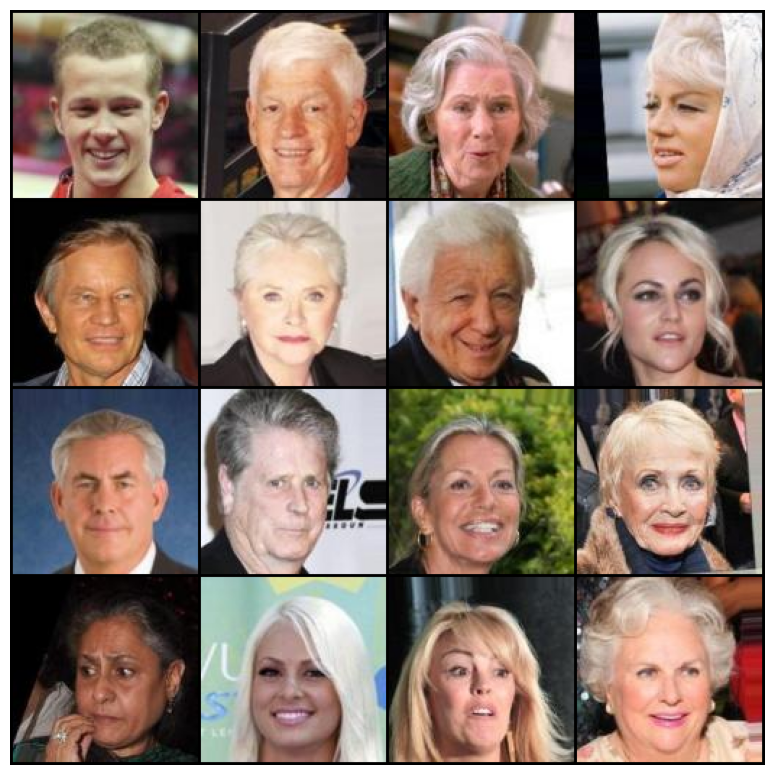

In [11]:
# plot the images
grid = make_grid(
    blond_hair_batch, nrow=4, normalize=True, value_range=(0, 1)
)  # Normalizes images to [0, 1]


# Option 2: Display the grid using matplotlib
def tensor_to_numpy(image_tensor):
    # Convert from tensor to NumPy for plotting
    image = image_tensor.cpu().permute(1, 2, 0)  # (C, H, W) -> (H, W, C)
    return image.numpy()


# Convert the grid to a NumPy array and display
grid_np = tensor_to_numpy(grid)
plt.figure(figsize=(8, 8))
plt.imshow(grid_np)
plt.axis("off")
plt.show()

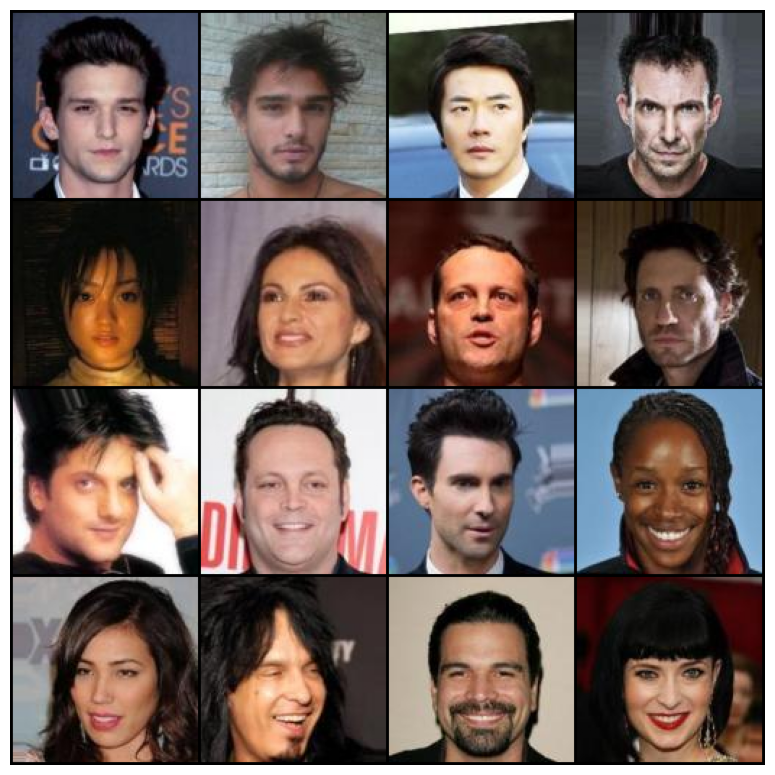

In [12]:
# plot the images
grid = make_grid(
    black_hair_batch, nrow=4, normalize=True, value_range=(0, 1)
)  # Normalizes images to [0, 1]


# Option 2: Display the grid using matplotlib
def tensor_to_numpy(image_tensor):
    # Convert from tensor to NumPy for plotting
    image = image_tensor.cpu().permute(1, 2, 0)  # (C, H, W) -> (H, W, C)
    return image.numpy()


# Convert the grid to a NumPy array and display
grid_np = tensor_to_numpy(grid)
plt.figure(figsize=(8, 8))
plt.imshow(grid_np)
plt.axis("off")
plt.show()

# Determine Latent Space Highly Correlated with Hair Color

Now, we will sample 10_000 images and their corresponding hair color, and iterate over the latent space of the beta-VAE, and then find a 4-dimensional vector with high correlation.

1. Generate embeddings of the dataset
2. Compute logistic-regression of four dimensional vector subspaces to the hair color label
3. Find model with the highest R^2 value
4. Proceed with that four dimensional vector subspace

In [36]:
imgs = []
labels = []
targets = []

for idx in range(len(causal_celeba_dataset)):
    _, img, _, interv_target, meta_label = causal_celeba_dataset[idx]
    label = meta_label[2]
    if idx == 0:
        print(label, meta_label)
    imgs.append(img.reshape(1, *img.shape))
    labels.append(label)
    targets.append(interv_target)

imgs = torch.vstack(imgs)
# labels = torch.vstack(labels)
targets = torch.vstack(targets)
print(imgs.shape, len(labels), targets.shape)

Black ['Male', 'Old', 'Black', 22439, 'obs', 0]
torch.Size([80000, 3, 128, 128]) 80000 torch.Size([80000, 3])


In [37]:
# Filter hair colors to only include those in labels
filtered_hair_colors = np.unique(labels, axis=0)

# Label Encoding (assigns a unique integer to each category)
label_encoder = LabelEncoder()
label_encoded = label_encoder.fit_transform(filtered_hair_colors)
print("Label Encoded:", label_encoded)

# One-Hot Encoding (binary vectors for each category)
one_hot_encoder = OneHotEncoder()
label_encoded_reshaped = label_encoded.reshape(-1, 1)  # Reshape for OneHotEncoder
one_hot_encoded = one_hot_encoder.fit_transform(label_encoded_reshaped)
print("One-Hot Encoded:")
print(one_hot_encoded)

# Decoding example
decoded_labels = label_encoder.inverse_transform(label_encoded)
print("Decoded Labels:", decoded_labels)


Label Encoded: [0 1 2]
One-Hot Encoded:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3 stored elements and shape (3, 3)>
  Coords	Values
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
Decoded Labels: ['Black' 'Blond' 'Gray']


# Embed Random Sample of Images and Determine Best Subset of Latent Space

In [ ]:

# now forward these through the model
indices = np.arange(len(imgs))
embeddings = []
y_true = []

with torch.no_grad():
    for idx in tqdm(np.array_split(indices[::5], 100)):
        this_embedding, logvar = vae_model.encoder.encode(imgs[idx, ...].to(device))
        embeddings.append(this_embedding)

        label_encoded = label_encoder.fit_transform([labels[i] for i in idx])
        y_true.extend(label_encoded)

        # Explicitly delete variables and clear cache
        del this_embedding, logvar
        torch.cuda.empty_cache()  # Clear unused memory from GPU

# embeddings = torch.vstack(embeddings)
y_true = torch.tensor(y_true)
print(embeddings.shape)
print(y_true.shape)

100%|██████████| 100/100 [00:00<00:00, 8663.77it/s]

torch.Size([16000])


In [61]:
rng = np.random.default_rng(12345)
hc_dim = 8
# y_true = y_true.cpu().numpy()

# Random grid search over 4D subspaces
num_trials = 1000  # Number of random subspaces to evaluate
best_score = 0
best_subset = None

for _ in tqdm(range(num_trials)):
    subset = rng.choice(embeddings.shape[1], hc_dim, replace=False)  # Select 4 random dimensions
    X_subset = embeddings[:, subset].cpu().numpy()  # Extract features

    model = LogisticRegression(fit_intercept=True)
    score = np.mean(cross_val_score(model, X_subset, y_true, cv=5))  # 5-fold CV
    
    if score > best_score:
        best_score = score
        best_subset = subset

print(f"Best subset: {best_subset} with score: {best_score}")

100%|██████████| 1000/1000 [00:28<00:00, 35.11it/s]

Best subset: [ 1 31 34 15 26 41 47 35] with score: 0.6330000000000001


In [13]:
best_subset = [1, 31, 34, 15, 26, 41, 47, 35]

In [14]:
# best_subset is now the most correlated with hair color, so we will perturb it
def exchange_latent_space(img_batch_A, img_batch_B, best_subset):
    img_batch_A[:, best_subset], img_batch_B[:, best_subset] = (
        img_batch_B[:, best_subset],
        img_batch_A[:, best_subset],
    )
    return img_batch_A, img_batch_B

with torch.no_grad():
    # encode
    blond_rep, _ = vae_model.encoder.encode(blond_hair_batch.to(device))
    black_rep, _ = vae_model.encoder.encode(black_hair_batch.to(device))

    # exchange
    blond_rep, black_rep = exchange_latent_space(blond_rep, black_rep, best_subset=best_subset)

    print(blond_rep.shape, black_rep.shape)

    # reconstruct
    blond_hair_recon = vae_model.decode(blond_rep)
    black_hair_recon = vae_model.decode(black_rep)

    print(blond_hair_recon.shape, black_hair_recon.shape)

torch.Size([16, 48]) torch.Size([16, 48])
torch.Size([16, 3, 128, 128]) torch.Size([16, 3, 128, 128])


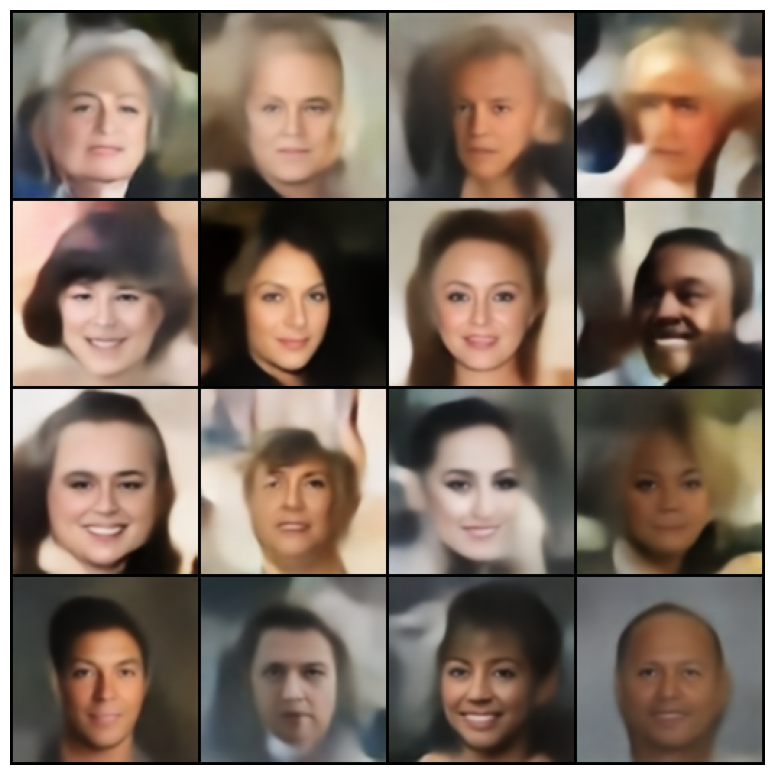

In [16]:

# plot the images
grid = make_grid(
    black_hair_recon, nrow=4, normalize=True, value_range=(0, 1)
)  # Normalizes images to [0, 1]


# Option 2: Display the grid using matplotlib
def tensor_to_numpy(image_tensor):
    # Convert from tensor to NumPy for plotting
    image = image_tensor.cpu().permute(1, 2, 0)  # (C, H, W) -> (H, W, C)
    return image.numpy()


# Convert the grid to a NumPy array and display
grid_np = tensor_to_numpy(grid)
plt.figure(figsize=(8, 8))
plt.imshow(grid_np)
plt.axis("off")
plt.show()

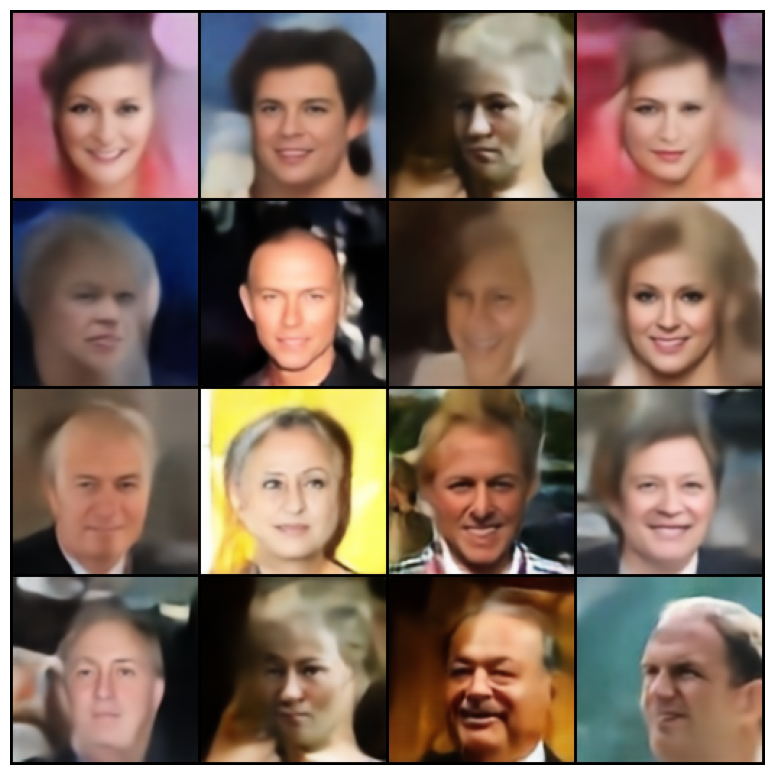

In [17]:

# plot the images
grid = make_grid(
    blond_hair_recon, nrow=4, normalize=True, value_range=(0, 1)
)  # Normalizes images to [0, 1]


# Option 2: Display the grid using matplotlib
def tensor_to_numpy(image_tensor):
    # Convert from tensor to NumPy for plotting
    image = image_tensor.cpu().permute(1, 2, 0)  # (C, H, W) -> (H, W, C)
    return image.numpy()


# Convert the grid to a NumPy array and display
grid_np = tensor_to_numpy(grid)
plt.figure(figsize=(8, 8))
plt.imshow(grid_np)
plt.axis("off")
plt.show()

## DDPM Unblur



In [68]:
# 128x128
# load DDPM and apply upscaling to image
input_res = 128
attn_resolutions = "16,"
dim_mults = "1,2,2,3,4"
n_channels = 3
dim = 128
n_residual = 2
dropout = 0.0
n_heads = 1
z_dim = 1024
type = "form1"
beta1 = 0.0001
beta2 = 0.02
n_timesteps = 1000
variance = "fixedsmall"
guidance_weight = 0.0
resample_strategy = "spaced"
skip_strategy = "uniform"
sample_method = "ddpm"
sample_from = "target"
seed = 0
n_samples = 50000
n_steps = 1000
workers = 2
batch_size = 8
save_vae = False
sample_prefix = ""
temp = 1.0
norm = True
# chkpt_path = "out/diffusion/diffvae_chq128_form1_loss=0.0066.ckpt"
# vae_chkpt_path = "out/diffusion/vae_chq128_alpha=1.0_loss=0.0000.ckpt"
chkpt_path = "/local/eb/adam2392/diffvae_chq128_form1_loss=0.0066.ckpt"
vae_chkpt_path = "/local/eb/adam2392/vae_chq128_alpha=1.0_loss=0.0000.ckpt"

z_cond = False

torch.cuda.empty_cache()
ddpm_device = torch.device(f"cuda:{1}")

In [69]:
def __parse_str(s):
    split = s.split(",")
    return [int(s) for s in split if s != "" and s is not None]

vae_backup = BACKVAE.load_from_checkpoint(
    vae_chkpt_path,
    input_res=input_res,
)
vae_backup.eval()

attn_resolutions = __parse_str(attn_resolutions)
dim_mults = __parse_str(dim_mults)
z_cond = False

decoder = SuperResModel(
    in_channels=n_channels,
    model_channels=dim,
    out_channels=3,
    num_res_blocks=n_residual,
    attention_resolutions=attn_resolutions,
    channel_mult=dim_mults,
    use_checkpoint=False,
    dropout=dropout,
    num_heads=n_heads,
    z_dim=z_dim,
    use_scale_shift_norm=z_cond,
    use_z=z_cond,
)

ema_decoder = copy.deepcopy(decoder)
decoder.eval()
ema_decoder.eval()

ddpm_cls = DDPMv2 if type == "form2" else DDPM
online_ddpm = ddpm_cls(
    decoder,
    beta_1=beta1,
    beta_2=beta2,
    T=n_timesteps,
    var_type=variance,
)

target_ddpm = ddpm_cls(
    ema_decoder,
    beta_1=beta1,
    beta_2=beta2,
    T=n_timesteps,
    var_type=variance,
)

online_ddpm.eval()
target_ddpm.eval()

ddpm_wrapper = DDPMWrapper.load_from_checkpoint(
    chkpt_path,
    online_network=online_ddpm,
    target_network=target_ddpm,
    vae=vae_backup,
    conditional=True,
    pred_steps=n_steps,
    eval_mode="vae_sample",
    resample_strategy=resample_strategy,
    skip_strategy=skip_strategy,
    sample_method=sample_method,
    sample_from=sample_from,
    data_norm=norm,
    temp=temp,
    guidance_weight=guidance_weight,
    z_cond=z_cond,
    ddpm_latents=None,
    strict=True,
)

ddpm_wrapper.to(ddpm_device)
ddpm_wrapper.eval()

print('done')

/home/adam2392/miniforge3/envs/ciflowsv2/lib/python3.10/site-packages/pytorch_lightning/utilities/migration/migration.py:208: You have multiple `ModelCheckpoint` callback states in this checkpoint, but we found state keys that would end up colliding with each other after an upgrade, which means we can't differentiate which of your checkpoint callbacks needs which states. At least one of your `ModelCheckpoint` callbacks will not be able to reload the state.
Lightning automatically upgraded your loaded checkpoint from v1.4.9 to v2.5.0.post0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../../../../local/eb/adam2392/vae_chq128_alpha=1.0_loss=0.0000.ckpt`
Lightning automatically upgraded your loaded checkpoint from v1.4.9 to v2.5.0.post0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../../../../local/eb/adam2392/diffvae_chq128_form1_loss=0.0066.ckpt`


done


In [70]:
def apply_ddpm_wrapper(ddpm_wrapper, reconstructed_imgs, temp=1.0, img_size=128, n_steps=1000):
    with torch.no_grad():
        # recons_inter = torch.randn(batch_size, 3, input_res, input_res).to(device)
        device = reconstructed_imgs.device
        x_t = (temp * torch.randn_like(reconstructed_imgs)).to(device)

        ddpm_latents = torch.randn(n_steps, 3, img_size, img_size).to(device)

        ddpm_sample = ddpm_wrapper(
            x_t,
            cond=reconstructed_imgs,
            z=None,
            n_steps=n_steps,
            ddpm_latents=ddpm_latents,
        )[str(n_steps)].cpu()

    return ddpm_sample


In [71]:
ddpm_samples = apply_ddpm_wrapper(
    ddpm_wrapper, black_hair_recon, temp=1.0, img_size=128, n_steps=1000
)

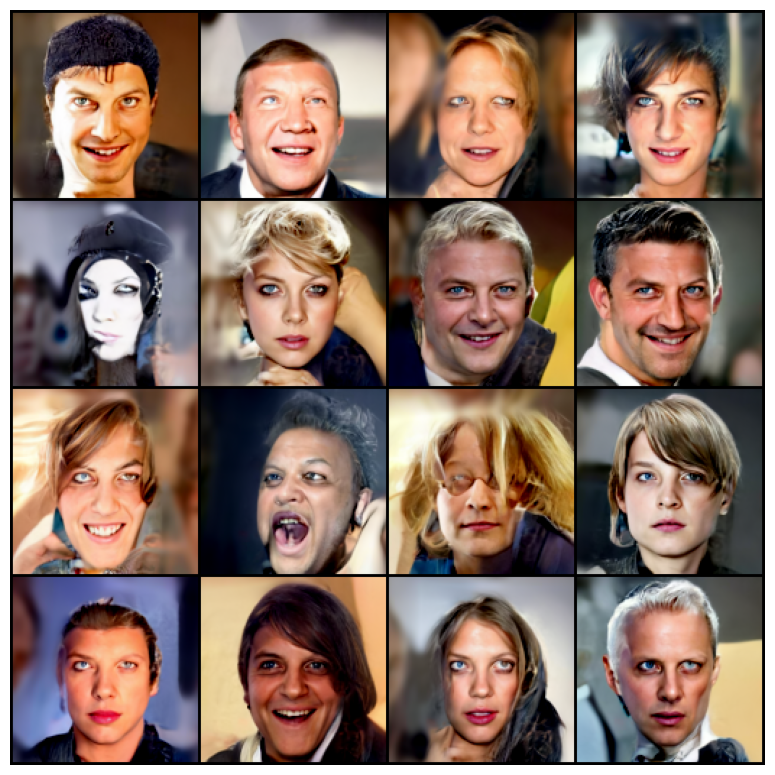

In [72]:
# -4
# plot the images
grid = make_grid(ddpm_samples, nrow=4, normalize=True, value_range=(0, 1))  # Normalizes images to [0, 1]

# Option 1: Save the grid to a file
save_image(grid, "image_grid.png")

# Option 2: Display the grid using matplotlib
def tensor_to_numpy(image_tensor):
    # Convert from tensor to NumPy for plotting
    image = image_tensor.cpu().permute(1, 2, 0)  # (C, H, W) -> (H, W, C)
    return image.numpy()

# Convert the grid to a NumPy array and display
grid = torch.clamp(grid, -1, 1)
grid_np = tensor_to_numpy(grid)
plt.figure(figsize=(8, 8))
plt.imshow(grid_np)
plt.axis('off')
plt.show()


# Apply hair-color predictor to all the images that were sampled

First, load the hair color predictor

In [15]:
model_fname = "celeba_dim128_genderpredictor_batch512_v1"
checkpoint_dir = root / "CausalCelebA" / "pretrained" / model_fname.split(".")[0]
model_path = checkpoint_dir / 'model_epoch_985.pt'

print("Loading predictor model from: ", model_path)
# Initialize the model, optimizer, and scheduler
predictor_model = MultiTaskResNet().to(device)
predictor_model, _ = load_model(predictor_model, model_path, device)
predictor_model = predictor_model.to(device)


Loading predictor model from:  /local/eb/adam2392/CausalCelebA/pretrained/celeba_dim128_genderpredictor_batch512_v1/model_epoch_985.pt
Model loaded from /local/eb/adam2392/CausalCelebA/pretrained/celeba_dim128_genderpredictor_batch512_v1/model_epoch_985.pt


/home/adam2392/projects/ciflows/ciflows/eval.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


In [16]:
# Function to predict hair color for a dataset
def predict_hair_color(model, images, device):
    model.to(device)
    model.eval()
    all_probs = []
    with torch.no_grad():
        images = images.to(device)
        _, hair_probs = model(images)
        all_probs.append(hair_probs.cpu())
    return torch.cat(all_probs, dim=0)

def predict_gender(model, images, device):
    model.to(device)
    model.eval()
    all_probs = []
    with torch.no_grad():
        images = images.to(device)
        gender_logits, gender_probs = model(images)
    return gender_probs.cpu()
        # all_probs.append(gender_probs.cpu())
    # return torch.cat(all_probs, dim=0)

In [21]:
male_orig_probs = []
male_pert_probs = []

# Get predictions
n_batches = 10
batch_size = 32
rng = np.random.default_rng(1234567)
# from causal to get the same indices
seeds = [3027154959, 4267703185, 513909820, 33364386, 2369766077, 1020888764, 3506176409, 3317523478, 2086019386, 1293991386]
for idx in tqdm(range(n_batches)):
    # Generate the next seed
    next_seed = rng.integers(0, 2**32)  # Generates a random 32-bit unsigned integer
    next_seed = seeds[idx]
    blond_hair_batch, blond_idx = causal_celeba_dataset.sample(
        n_samples=batch_size, attr_name="Hair Color", attr_val='Gray', seed=next_seed,
    )

    black_hair_batch, black_idx = causal_celeba_dataset.sample(
        n_samples=batch_size, attr_name="Hair Color", attr_val='Black', seed=next_seed,
    )

    # concatenate images
    imgs = torch.cat((blond_hair_batch, black_hair_batch), dim=0)

    # XXX: we should also load in the true gender labels
    gender_original = predict_gender(predictor_model, imgs, device)

    # swap the latent space and then get the swapped images
    with torch.no_grad():
        # encode
        blond_rep, _ = vae_model.encoder.encode(blond_hair_batch.to(device))
        black_rep, _ = vae_model.encoder.encode(black_hair_batch.to(device))

        # exchange
        blond_rep, black_rep = exchange_latent_space(blond_rep, black_rep, best_subset=best_subset)

        # print(blond_rep.shape, black_rep.shape)

        # reconstruct
        blond_hair_recon = vae_model.decode(blond_rep)
        black_hair_recon = vae_model.decode(black_rep)

        # print(blond_hair_recon.shape, black_hair_recon.shape)
    swapped_imgs = torch.cat((blond_hair_recon, black_hair_recon), dim=0)
    gender_perturbed = predict_gender(predictor_model, swapped_imgs, device)
    gender_original = gender_original[:, 1].numpy().tolist()
    gender_perturbed = gender_perturbed[:, 1].numpy().tolist()

    male_orig_probs.extend(gender_original)
    male_pert_probs.extend(gender_perturbed)

    # break
# Print results
print("Gender probabilities for original images:", gender_original)
print("Hair color probabilities for perturbed images:", gender_perturbed)


100%|██████████| 10/10 [00:00<00:00, 10.32it/s]

Gender probabilities for original images: [0.9998611211776733, 0.9999966621398926, 0.9997524619102478, 0.9936263561248779, 0.03317120671272278, 0.2019186019897461, 0.001353374682366848, 0.6893494129180908, 0.6692431569099426, 0.17796778678894043, 0.9978708028793335, 0.9952192902565002, 3.8309619412757456e-05, 0.37907013297080994, 0.0011997243855148554, 0.0013896411983296275, 0.0004140286473557353, 0.9999831914901733, 0.9998483657836914, 0.9374876022338867, 0.9923056960105896, 0.999284565448761, 3.115422441624105e-05, 0.9067109823226929, 0.0018180322367697954, 0.999988317489624, 0.9967761635780334, 3.8309619412757456e-05, 0.9969058632850647, 0.027904042974114418, 0.2948881983757019, 0.005901426542550325, 0.04655895754694939, 0.99000084400177, 0.004540842957794666, 0.004132466856390238, 0.3185528814792633, 0.003350499551743269, 0.9959810972213745, 0.999887228012085, 0.9909369349479675, 0.9445743560791016, 0.009967145510017872, 0.9999669790267944, 0.05397108197212219, 0.9997532963752747, 

In [22]:
# gender_original = gender_original[:, 1].numpy()
# gender_perturbed = gender_perturbed[:, 1].numpy()

print(np.array(male_orig_probs).shape)
# print(gender_perturbed.shape)

(640,)


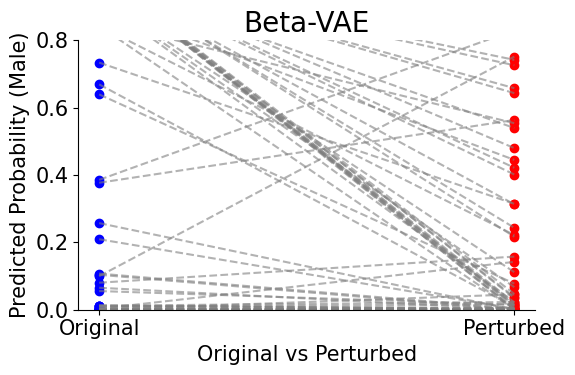

In [23]:
# Create index positions for pairs
rng = np.random.default_rng(1)
# rng_idx = rng.choice(np.arange(len(male_orig_probs)), size=(32,),  replace=False)
rng_idx = [311, 54, 237, 76, 133, 41, 246, 316, 65, 121, 344, 6, 124, 325, 144, 139, 40, 72, 247, 275, 94, 80, 328, 262, 20, 8, 109, 142, 30, 192, 10, 145, 242, 243, 164, 250, 319, 255, 307, 244, 254, 42, 101, 91, 181, 128, 312, 331, 271, 25, 93, 159, 177, 161, 215, 305, 98, 162, 288, 229, 323, 38, 84, 309]
orig_probs = np.array(male_orig_probs)[rng_idx]
pert_probs = np.array(male_pert_probs)[rng_idx]

arg_idx = np.argsort(orig_probs)
orig_probs = orig_probs[arg_idx]
pert_probs = pert_probs[arg_idx]

og_indices = [0] * len(orig_probs)
perturbed_indices = [1] * len(pert_probs)

# Plot paired probabilities
fig, ax = plt.subplots(figsize=(6, 4))
plt.scatter(og_indices, orig_probs, color="blue", 
            # label="Model 1"
            )
plt.scatter(perturbed_indices, pert_probs, color="red", 
            # label="Model 2"
            )

# Connect pairs with lines
# for i in range(len(male_orig_probs)):
plt.plot(
    [og_indices, perturbed_indices],
    [orig_probs, pert_probs],
    "gray",
    linestyle="--",
    alpha=0.6,
)

plt.xticks([0, 1])
ax.set_ylim([0.0, 0.8])
ax.set_xticklabels(['Original', 'Perturbed'])
plt.xlabel("Original vs Perturbed")
plt.ylabel("Predicted Probability (Male)")
plt.title("Beta-VAE")
# plt.legend()
plt.show()

In [20]:
from scipy.stats import ttest_rel, wilcoxon, ttest_ind

# Perform paired t-test
t_stat, p_value = ttest_rel(orig_probs, pert_probs)

# Print results
print(t_stat, p_value)


# Perform paired t-test
t_stat, p_value = ttest_ind(orig_probs, pert_probs)

# Print results
print(t_stat, p_value)

# Perform Wilcoxon signed-rank test
w_stat, p_value = wilcoxon(orig_probs, pert_probs)

# Print results
print("Wilcoxon signed-rank test results:")
print(f"Statistic: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

6.409385032486101 2.112635173450268e-08
4.904420896682743 2.831591384675214e-06
Wilcoxon signed-rank test results:
Statistic: 231.0000
P-value: 0.0000
